In [6]:
# Importazione delle librerie necessarie
import pandas as pd
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

# 1. Caricamento del dataset
file_path = 'Balanced_IEC104_Train_Test_CSV_Files/iec104_train_test_csvs/tests_cic_15/train_15_cicflow.csv'  # Sostituisci con il percorso corretto al tuo file CSV
df = pd.read_csv(file_path)

# 2. Creazione dei metadati
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# 3. Inizializzazione e addestramento del sintetizzatore
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)

# 4. Generazione dei dati sintetici
num_rows = len(df)  # Puoi modificare questo valore per generare un numero diverso di righe
synthetic_data = synthesizer.sample(num_rows=num_rows)

# 5. Salvataggio dei dati sintetici in un nuovo file CSV
output_path = 'dataset_sintetico.csv'  # Sostituisci con il percorso desiderato per il file di output
synthetic_data.to_csv(output_path, index=False)

# 6. Valutazione della qualità dei dati sintetici
quality_report = evaluate_quality(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)

# Visualizzazione del punteggio complessivo di qualità
print("Punteggio complessivo di qualità:", quality_report.get_score())


/tmp/ipykernel_2114966/3859549851.py:9: DtypeWarning:

Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.

/home/habes/anaconda3/envs/llmenv/lib/python3.10/site-packages/sdv/single_table/base.py:145: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/home/habes/anaconda3/envs/llmenv/lib/python3.10/site-packages/sdv/single_table/base.py:123: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 84/84 [00:00<00:00, 93.89it/s]| 
Column Shapes Score: 69.43%

(2/2) Evaluating Column Pair Trends: |██████████| 3486/3486 [00:32<00:00, 106.28it/s]|
Column Pair Trends Score: 78.68%

Overall Score (Average): 74.05%

Punteggio complessivo di qualità: 0.7405218739546215


/tmp/ipykernel_2114966/3997538979.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




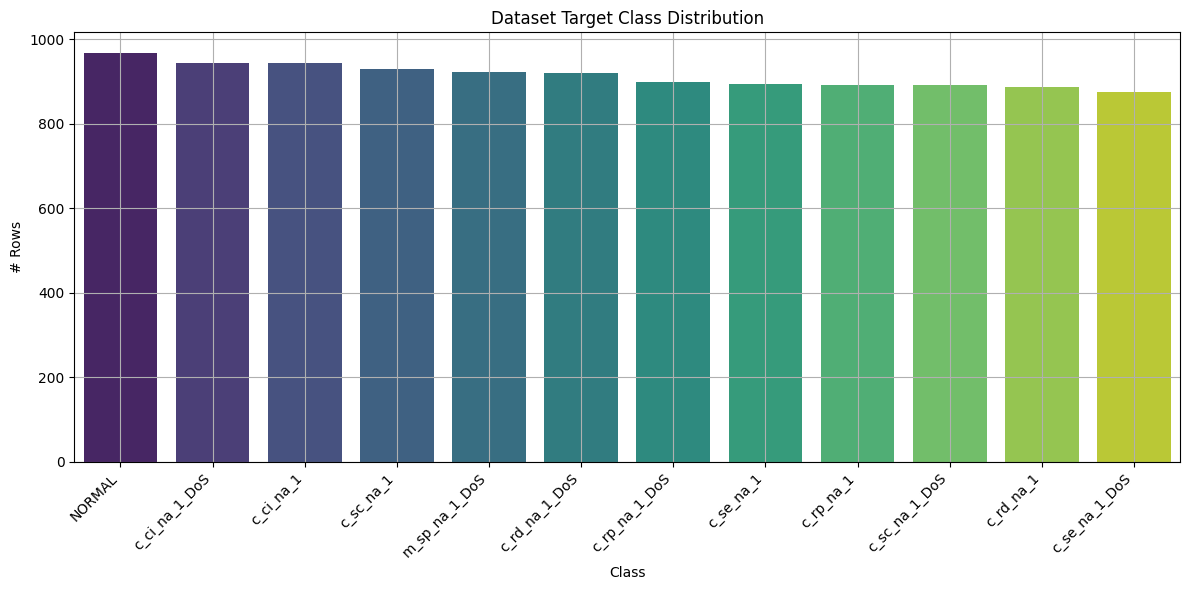

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the synthetic dataset
file_path = 'dataset_sintetico.csv'
df = pd.read_csv(file_path)

# Check if 'Label' column exists
if 'Label' in df.columns:
    # Display the class distribution
    class_counts = df['Label'].value_counts()

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
    plt.title("Dataset Target Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("# Rows")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(True)
    plt.show()
else:
    print("Il dataset non contiene una colonna 'Label'.")


In [8]:
df

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.1.22-192.168.1.29-2404-44061-6,192.168.1.29,48218,192.168.1.19,2361.258587,40.666667,05/06/2020 02:04:31 PM,10493909,2,8,...,0.0,4242276.8,3.117674e+05,4245880.0,4178529.0,7343243.6,2.773504e+06,7341821.0,7338460.0,c_ci_na_1_DoS
1,192.168.1.19-192.168.1.29-2404-33795-6,192.168.1.29,29358,192.168.1.13,2544.028872,40.666667,28/04/2020 09:35:34 PM,2480863,1,4,...,0.0,1780.8,2.497358e+06,1826.0,215.0,361.8,8.370061e+04,348.0,376.0,c_se_na_1
2,192.168.1.13-192.168.1.29-2404-39165-6,192.168.1.29,39018,192.168.1.13,2624.151268,40.666667,26/04/2020 11:17:05 PM,11955535,1,23,...,0.0,328163.8,3.186651e+03,325079.0,167761.0,472762.0,3.416529e+03,467267.0,481845.0,c_rd_na_1_DoS
3,192.168.1.22-192.168.1.29-2404-38747-6,192.168.1.20,45214,192.168.1.19,2331.419513,40.666667,27/04/2020 08:30:55 PM,10648834,2,3,...,0.0,1998884.9,2.519413e+06,2010202.0,1463288.0,2527746.9,3.119226e+05,2530603.0,2523506.0,c_rp_na_1
4,192.168.1.22-192.168.1.29-2404-42981-6,192.168.1.29,39582,192.168.1.19,2522.166981,40.666667,06/06/2020 02:40:29 PM,997664,1,2,...,0.0,67697.0,4.240794e+05,67491.0,18701.0,684788.7,1.679590e+06,690596.0,680135.0,c_ci_na_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10963,192.168.1.22-192.168.1.29-2404-43673-6,192.168.1.28,32472,192.168.1.19,2508.056793,40.666667,29/04/2020 03:21:34 PM,201397,1,2,...,0.0,46804.2,1.767199e+04,46695.0,14933.0,2116.5,5.459846e+05,2171.0,2096.0,c_sc_na_1_DoS
10964,192.168.1.25-192.168.1.27-2404-45661-6,192.168.1.27,32292,192.168.1.19,2187.286108,40.666667,25/04/2020 12:51:02 AM,3150074,1,10,...,0.0,0.3,2.524418e+06,0.0,0.0,0.0,3.932825e+05,0.0,0.0,m_sp_na_1_DoS
10965,192.168.1.25-192.168.1.27-2404-38263-6,192.168.1.29,39687,192.168.1.22,2655.901787,40.666667,28/04/2020 02:24:34 PM,8886236,1,6,...,0.0,14589.3,3.865969e+04,14702.0,2054.0,299.2,6.400553e+04,290.0,309.0,c_se_na_1
10966,192.168.1.13-192.168.1.29-2404-37025-6,192.168.1.29,49124,192.168.1.25,2630.894360,40.666667,27/04/2020 07:41:47 PM,14578223,5,10,...,0.0,955070.1,2.901244e-01,948981.0,609627.0,119837.4,4.765833e+03,118110.0,120216.0,c_se_na_1_DoS


/tmp/ipykernel_2114966/4113347960.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




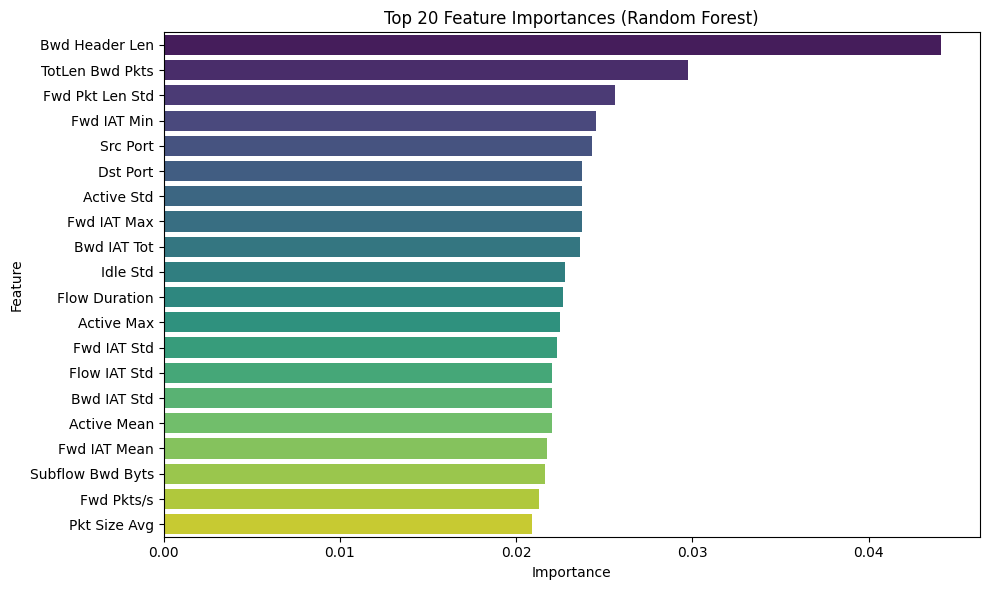

In [9]:
# Importazione librerie
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Caricamento del dataset
file_path = 'dataset_sintetico.csv'  # Usa il percorso corretto se diverso
df = pd.read_csv(file_path)

# Seleziona solo le colonne numeriche e aggiungi l'etichetta
df_numeric = df.select_dtypes(include=[np.number])
if 'Label' not in df_numeric.columns and 'Label' in df.columns:
    df_numeric['Label'] = df['Label']

# Codifica delle etichette (Label encoding)
le = LabelEncoder()
y = le.fit_transform(df['Label'])

# Escludi la colonna 'Label' dalle feature
X = df_numeric.drop(columns=['Label'])

# Gestione dei valori mancanti (imputazione con la mediana)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Suddivisione in training e test
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)

# Addestramento del modello Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Calcolo delle feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualizzazione delle top 20 feature
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()
